In [1]:
#%% import pytorch 
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt


Text(0.5, 1.0, 'Simulated Data')

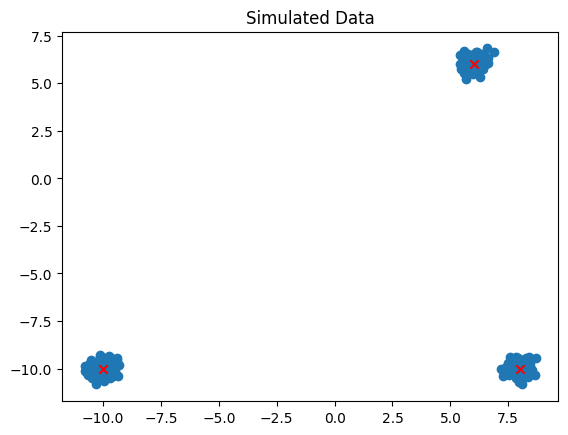

In [2]:

# %%

# simulate data
gaussian_centers = torch.tensor([[-10., -10], [6, 6], [8, -10]])  # 3 centers of 2-d gaussian

gaussian_std = torch.tensor(0.1)
num_samples = 100


#%%
seed = 42
torch.manual_seed(seed)

Gaussian = MultivariateNormal(gaussian_centers.reshape(-1), 
                              covariance_matrix=torch.eye(gaussian_centers.shape[0] * gaussian_centers.shape[1]) * gaussian_std)

data = Gaussian.sample((num_samples,))
data = torch.cat(torch.split(data, gaussian_centers.shape[1], dim=1))  # z
# %%

plt.scatter(data[:, 0], data[:, 1])
plt.scatter(gaussian_centers[:, 0], gaussian_centers[:, 1], c='red', marker='x')
plt.title('Simulated Data')


In [12]:
# %%
# Linear time schedular Gaussian Flow matching 
T = 1000 

# X = alpha_t * z + beta_t * e, X_0 = e, X_T = z
z = data
alpha_t = torch.linspace(0, 1, T)
beta_t = torch.linspace(1, 0, T)


data_loader = torch.utils.data.DataLoader(data, batch_size=32, shuffle=True)

# learn the ODE flow gradient u(x, t) = dX_t/dt
theta_model = nn.Sequential(
    nn.Linear(3, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
)

optimizer = torch.optim.Adam(theta_model.parameters(), lr=0.001)
loss_fun = nn.MSELoss()

Loss_record= []

total_epochs = 100
for epoch in range(100):
    print(f'Epoch {epoch+1}/{total_epochs}')
    for z in data_loader:
        t = torch.randint(0, T, (z.shape[0],)) # random time steps
        e = torch.normal(mean= 0., std = 1., size=z.shape)  # noise
        x = alpha_t[t].unsqueeze(-1) * z + beta_t[t].unsqueeze(-1) * e  # X_t = alpha_t * z + beta_t * e
        
        input_data = torch.cat((x, t.unsqueeze(1)/T), dim=1)
        
        
        flow_gradient_pred = theta_model(input_data)
        optimizer.zero_grad()
        loss = loss_fun(flow_gradient_pred, z - e)
        loss.backward()
        optimizer.step()
        Loss_record.append(loss.item())
        
   

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

Text(0.5, 1.0, 'Training Loss for Flow Matching Model')

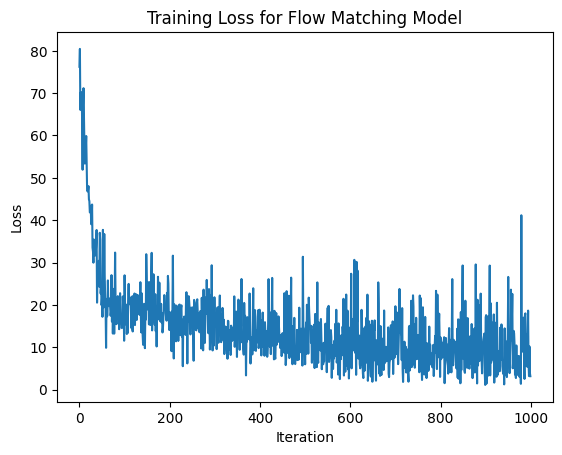

In [13]:
     
#%%
plt.plot(Loss_record)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss for Flow Matching Model')



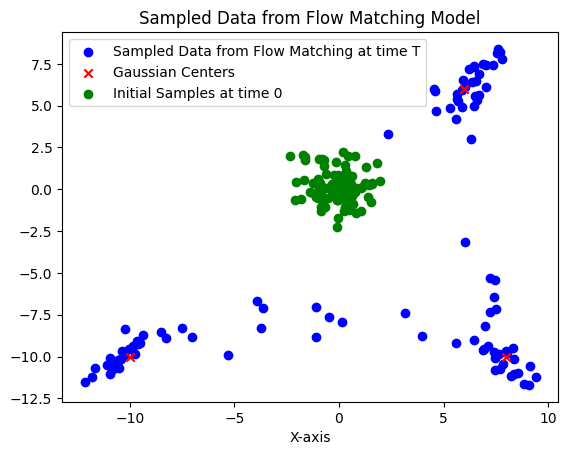

In [15]:


# %%
# Sample from trained model
X_0 = torch.normal(mean=0., std=1., size=(100, 2))

with torch.no_grad():
    x = X_0.clone()
    for t in range(T):
        t_norm = torch.full((X_0.shape[0],), t / T)
        input_data = torch.cat((x, t_norm.unsqueeze(1)), dim=1)
        flow_gradient_pred = theta_model(input_data)
        x = x +  1/T * flow_gradient_pred  # Euler step
        
    
    
    
#%%
plt.scatter(x[:, 0], x[:, 1], c='blue', marker='o', label='Sampled Data from Flow Matching at time T')
plt.scatter(gaussian_centers[:, 0], gaussian_centers[:, 1], c='red', marker='x', label='Gaussian Centers')
plt.scatter(X_0[:, 0], X_0[:, 1], c='green', marker='o', label='Initial Samples at time 0')
plt.xlabel('X-axis')
plt.title('Sampled Data from Flow Matching Model')
plt.legend()
# %%
